# Evaluasi Model Terbaik

**Tujuan**: Mendetailkan hasil (metrics & confusion matrix) dari model terbaik hasil eksperimen di `modelling.ipynb`

**Model yang dievaluasi:**
- `model/sentiment/inference_v1.joblib` — LogisticRegression(C=10) — Varian Sent+Basic (TF-IDF + Basic11)
- `model/emotion/inference_v1.joblib` — SMOTE + LogisticRegression(C=0.1) — Varian Emo+Basic+Sent

In [34]:
import pandas as pd
import numpy as np
import itertools
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

import matplotlib.pyplot as plt
import joblib
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except:
    pass

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Resolve paths relative to project root
notebook_dir = Path.cwd()
if notebook_dir.name == 'notebooks':
    BASE_DIR = notebook_dir.parent
else:
    BASE_DIR = notebook_dir

## 1. Load Data & Train/Test Split

In [35]:
intermediate_dir = BASE_DIR / 'data' / 'intermediate'
cache_path = intermediate_dir / 'preprocessed_reviews.csv'

if not cache_path.exists():
    raise FileNotFoundError(
        'Preprocessed data not found. Run preprocessing.ipynb first.'
    )

df = pd.read_csv(cache_path)
print(f'Total rows: {len(df)}')
print(f'\nSentiment distribution:\n{df["Sentiment"].value_counts()}')
print(f'\nEmotion distribution:\n{df["Emotion"].value_counts()}')

Total rows: 5400

Sentiment distribution:
Sentiment
Negative    2821
Positive    2579
Name: count, dtype: int64

Emotion distribution:
Emotion
Happy      1770
Sadness    1202
Fear        920
Love        809
Anger       699
Name: count, dtype: int64


In [36]:
X_raw_text = df['Customer Review'].fillna('')
X_raw_proc = df['text_processed'].fillna('')
y_emo = df['Emotion']
y_sen = df['Sentiment']

X_train_text, X_test_text, X_train_proc, X_test_proc, \
    y_train_emo, y_test_emo, y_train_sen, y_test_sen = train_test_split(
        X_raw_text, X_raw_proc, y_emo, y_sen,
        test_size=0.2, random_state=RANDOM_STATE
    )

print(f'Train size: {len(X_train_text)}, Test size: {len(X_test_text)}')
print(f'\n=== Class Distribution (Test) ===')
print(f'Sentiment:\n{y_test_sen.value_counts()}')
print(f'\nEmotion:\n{y_test_emo.value_counts()}')

Train size: 4320, Test size: 1080

=== Class Distribution (Test) ===
Sentiment:
Sentiment
Negative    557
Positive    523
Name: count, dtype: int64

Emotion:
Emotion
Happy      356
Sadness    253
Love       167
Fear       159
Anger      145
Name: count, dtype: int64


## 2. Feature Extraction Functions

Fungsi-fungsi ini diperlukan untuk mereproduksi feature engineering yang sama dengan saat training.

In [37]:
def extract_discriminative_features(series: pd.Series) -> pd.DataFrame:
    features = pd.DataFrame(index=series.index)

    demand_words = {'kembalikan', 'ganti', 'refund', 'komplain', 'keluhan',
                    'kembali', 'tolong', 'mohon', 'urus', 'klarifikasi',
                    'balas'}
    features['n_demands'] = series.apply(
        lambda x: sum(1 for w in str(x).lower().split() if w in demand_words)
    )

    uncertainty_words = {'mungkin', 'khawatir', 'takut', 'was-was', 'cemas',
                         'ragu', 'bimbang', 'curiga', 'sepertinya', 'seolah',
                         'antisipasi', 'harap'}
    features['n_uncertainty'] = series.apply(
        lambda x: sum(1 for w in str(x).lower().split() if w in uncertainty_words)
    )

    swear_words = {'anjing', 'bangsat', 'bodoh', 'tolol', 'jelek', 'parah',
                   'payah', 'sampah', 'busuk', 'brengsek', 'persetan',
                   'keparat', 'setan', 'sial', 'kacau'}
    features['n_swear'] = series.apply(
        lambda x: sum(1 for w in str(x).lower().split() if w in swear_words)
    )

    attachment_words = {'cinta', 'sayang', 'suka', 'gemas',
                        'love', 'favorit',
                        'kesayangan', 'favorite'}
    features['n_attachment'] = series.apply(
        lambda x: sum(1 for w in str(x).lower().split() if w in attachment_words)
    )

    repurchase_words = {'beli lagi', 'order lagi', 'repeat order', 'langganan',
                        'balik lagi', 'pasti beli', 'akan beli', 'nanti beli',
                        'rekomendasi', 'recommend', 'beli disini terus'}
    features['n_repurchase'] = series.apply(
        lambda x: sum(1 for phrase in repurchase_words if phrase in str(x).lower())
    )

    transactional_words = {'bagus', 'mantap', 'ok', 'oke', 'cocok', 'puas',
                           'sesuai', 'recommended', 'keren', 'mantul',
                           'top', 'good', 'nice', 'great', 'worth'}
    features['n_transactional'] = series.apply(
        lambda x: sum(1 for w in str(x).lower().split() if w in transactional_words)
    )

    return features


def extract_emotion_features(series: pd.Series) -> pd.DataFrame:
    """Basic 11 fitur: 5 punctuation + 6 discriminative"""
    features = pd.DataFrame(index=series.index)
    features['n_exclamation'] = series.apply(lambda x: x.count('!'))
    features['n_question'] = series.apply(lambda x: x.count('?'))
    features['n_allcaps'] = series.apply(
        lambda x: sum(1 for w in str(x).split() if w.isupper() and len(w) > 2)
    )
    features['n_ellipsis'] = series.apply(lambda x: x.count('..'))
    features['max_char_repeat'] = series.apply(
        lambda x: max(
            (len(list(g)) for _, g in itertools.groupby(str(x).lower())),
            default=0,
        )
    )

    discr = extract_discriminative_features(series)
    for col in discr.columns:
        features[col] = discr[col]

    return features

## 3. Load Saved Models & Vectorizers

In [38]:
model_dir = BASE_DIR / 'model'
sent_dir = model_dir / 'sentiment'
emo_dir = model_dir / 'emotion'

sent_model = joblib.load(sent_dir / 'inference_v1.joblib')
emo_model = joblib.load(emo_dir / 'inference_v1.joblib')
sent_vec = joblib.load(sent_dir / 'vectorizer_v1.joblib')
emo_vec = joblib.load(emo_dir / 'vectorizer_v1.joblib')

print('=== Sentiment Model (best dari modelling.ipynb) ===')
print(sent_model)
print(f'Expected features: {sent_model.named_steps["clf"].coef_.shape[1]}')

print('\n=== Emotion Model (best dari modelling.ipynb) ===')
print(emo_model)
print(f'Expected features: {emo_model.named_steps["clf"].coef_.shape[1]}')

print('\n=== Vectorizer (sama untuk sentimen & emosi) ===')
print(f'{sent_vec}')

=== Sentiment Model (best dari modelling.ipynb) ===
Pipeline(steps=[('clf',
                 LogisticRegression(C=10, max_iter=1000, random_state=42))])
Expected features: 1511

=== Emotion Model (best dari modelling.ipynb) ===
Pipeline(steps=[('sampler', SMOTE(k_neighbors=3, random_state=42)),
                ('clf',
                 LogisticRegression(C=0.1, max_iter=1000, random_state=42))])
Expected features: 1512

=== Vectorizer (sama untuk sentimen & emosi) ===
TfidfVectorizer(max_features=1500)


## 4. Evaluasi Sentiment Model

Menggunakan `model/sentiment/vectorizer_v1.joblib` (unigram TF-IDF, max_features=1500) + `model/sentiment/inference_v1.joblib` (LogisticRegression, C=10).

**Feature Variant: Sent+Basic** — TF-IDF + Basic11 = 1500 + 11 = **1511 fitur**

In [39]:
X_test_vec = sent_vec.transform(X_test_proc)
emo_basic_test = extract_emotion_features(X_test_text)
X_test_sent = hstack([X_test_vec, emo_basic_test.values]).tocsr()
print(f'Test feature shape: {X_test_sent.shape}')

pred_sent = sent_model.predict(X_test_sent)

Test feature shape: (1080, 1511)


In [40]:
acc = accuracy_score(y_test_sen, pred_sent)
prec = precision_score(y_test_sen, pred_sent, average='macro')
rec = recall_score(y_test_sen, pred_sent, average='macro')
f1 = f1_score(y_test_sen, pred_sent, average='macro')

print('=' * 60)
print('SENTIMENT MODEL — Metrics Summary')
print('=' * 60)
print(f'Model:           LogisticRegression(C=10)')
print(f'Vectorizer:      Unigram TF-IDF (max_features=1500)')
print(f'Feature Variant: Sent+Basic (TF-IDF + Basic11)')
print(f'\nAccuracy:         {acc:.4f}')
print(f'Precision (Macro): {prec:.4f}')
print(f'Recall (Macro):    {rec:.4f}')
print(f'F1-Score (Macro):  {f1:.4f}')
print('=' * 60)

SENTIMENT MODEL — Metrics Summary
Model:           LogisticRegression(C=10)
Vectorizer:      Unigram TF-IDF (max_features=1500)
Feature Variant: Sent+Basic (TF-IDF + Basic11)

Accuracy:         0.9250
Precision (Macro): 0.9253
Recall (Macro):    0.9246
F1-Score (Macro):  0.9249


In [41]:
print('=' * 60)
print('SENTIMENT MODEL — Classification Report')
print('=' * 60)
print(classification_report(y_test_sen, pred_sent))

SENTIMENT MODEL — Classification Report
              precision    recall  f1-score   support

    Negative       0.92      0.94      0.93       557
    Positive       0.93      0.91      0.92       523

    accuracy                           0.93      1080
   macro avg       0.93      0.92      0.92      1080
weighted avg       0.93      0.93      0.92      1080



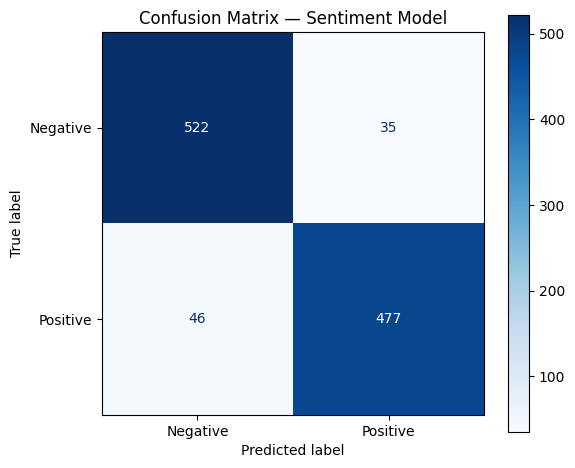

In [42]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_sen, pred_sent, ax=ax,
    cmap='Blues', values_format='d'
)
ax.set_title('Confusion Matrix — Sentiment Model')
plt.tight_layout()
plt.show()

## 5. Evaluasi Emotion Model

Menggunakan `model/emotion/vectorizer_v1.joblib` (unigram TF-IDF, max_features=1500) + Basic11 + sentiment indicator + `model/emotion/inference_v1.joblib` (SMOTE + LogisticRegression, C=0.1).

**Feature Variant: Emo+Basic+Sent** — TF-IDF + Basic11 + Sentiment Indicator = 1500 + 11 + 1 = **1512 fitur**

In [43]:
X_test_vec_emo = emo_vec.transform(X_test_proc)
print(f'Unigram TF-IDF shape: {X_test_vec_emo.shape}')

emo_basic_test = extract_emotion_features(X_test_text)
print(f'Basic11 features shape: {emo_basic_test.shape}')

sent_indicator = (y_test_sen == 'Positive').astype(int).values.reshape(-1, 1)
print(f'Sentiment indicator shape: {sent_indicator.shape}')

X_test_emo = hstack([
    X_test_vec_emo,
    emo_basic_test.values,
    sent_indicator
]).tocsr()
print(f'\nTotal test feature shape: {X_test_emo.shape}')

pred_emo = emo_model.predict(X_test_emo)

Unigram TF-IDF shape: (1080, 1500)
Basic11 features shape: (1080, 11)
Sentiment indicator shape: (1080, 1)

Total test feature shape: (1080, 1512)


In [44]:
acc_emo = accuracy_score(y_test_emo, pred_emo)
prec_emo = precision_score(y_test_emo, pred_emo, average='macro')
rec_emo = recall_score(y_test_emo, pred_emo, average='macro')
f1_emo = f1_score(y_test_emo, pred_emo, average='macro')

print('=' * 60)
print('EMOTION MODEL — Metrics Summary')
print('=' * 60)
print(f'Model:           SMOTE + LogisticRegression(C=0.1)')
print(f'Vectorizer:      Unigram TF-IDF (max_features=1500)')
print(f'Feature Variant: Emo+Basic+Sent (TF-IDF + Basic11 + Sentiment)')
print(f'\nAccuracy:         {acc_emo:.4f}')
print(f'Precision (Macro): {prec_emo:.4f}')
print(f'Recall (Macro):    {rec_emo:.4f}')
print(f'F1-Score (Macro):  {f1_emo:.4f}')
print('=' * 60)

EMOTION MODEL — Metrics Summary
Model:           SMOTE + LogisticRegression(C=0.1)
Vectorizer:      Unigram TF-IDF (max_features=1500)
Feature Variant: Emo+Basic+Sent (TF-IDF + Basic11 + Sentiment)

Accuracy:         0.7065
Precision (Macro): 0.6711
Recall (Macro):    0.6727
F1-Score (Macro):  0.6700


In [45]:
print('=' * 60)
print('EMOTION MODEL — Classification Report')
print('=' * 60)
print(classification_report(y_test_emo, pred_emo))

EMOTION MODEL — Classification Report
              precision    recall  f1-score   support

       Anger       0.58      0.52      0.55       145
        Fear       0.47      0.58      0.52       159
       Happy       0.88      0.85      0.87       356
        Love       0.71      0.75      0.73       167
     Sadness       0.72      0.65      0.68       253

    accuracy                           0.71      1080
   macro avg       0.67      0.67      0.67      1080
weighted avg       0.71      0.71      0.71      1080



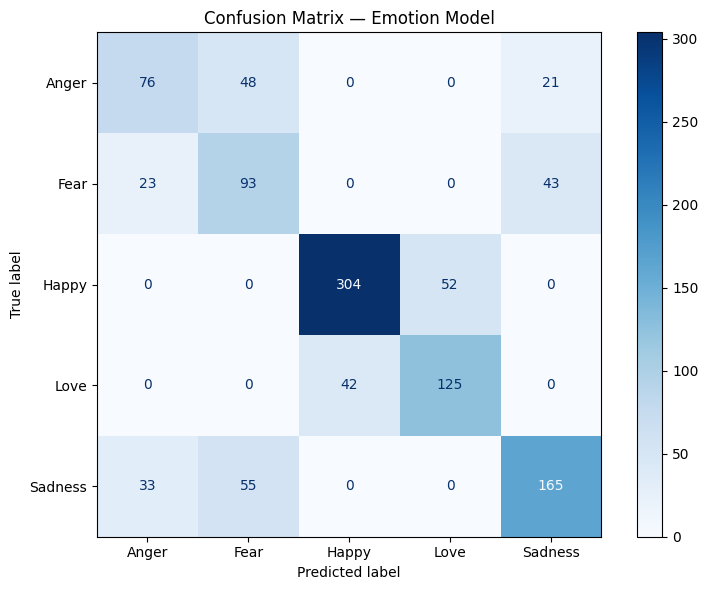

In [46]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test_emo, pred_emo, ax=ax,
    cmap='Blues', values_format='d'
)
ax.set_title('Confusion Matrix — Emotion Model')
plt.tight_layout()
plt.show()

## 6. Ringkasan Perbandingan

In [47]:
summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)'],
    'Sentiment': [f'{acc:.4f}', f'{prec:.4f}', f'{rec:.4f}', f'{f1:.4f}'],
    'Emotion':   [f'{acc_emo:.4f}', f'{prec_emo:.4f}', f'{rec_emo:.4f}', f'{f1_emo:.4f}'],
})
print(summary.to_string(index=False))

           Metric Sentiment Emotion
         Accuracy    0.9250  0.7065
Precision (Macro)    0.9253  0.6711
   Recall (Macro)    0.9246  0.6727
 F1-Score (Macro)    0.9249  0.6700


### Per-Class F1 Comparison

In [48]:
emo_report = classification_report(y_test_emo, pred_emo, output_dict=True)
sen_report = classification_report(y_test_sen, pred_sent, output_dict=True)

# Sentiment per-class
sen_rows = []
for cls in ['Negative', 'Positive']:
    sen_rows.append({
        'Task': 'Sentiment',
        'Class': cls,
        'Precision': f'{sen_report[cls]["precision"]:.4f}',
        'Recall': f'{sen_report[cls]["recall"]:.4f}',
        'F1-Score': f'{sen_report[cls]["f1-score"]:.4f}',
        'Support': int(sen_report[cls]['support']),
    })

# Emotion per-class
emo_rows = []
for cls in ['Anger', 'Fear', 'Happy', 'Love', 'Sadness']:
    emo_rows.append({
        'Task': 'Emotion',
        'Class': cls,
        'Precision': f'{emo_report[cls]["precision"]:.4f}',
        'Recall': f'{emo_report[cls]["recall"]:.4f}',
        'F1-Score': f'{emo_report[cls]["f1-score"]:.4f}',
        'Support': int(emo_report[cls]['support']),
    })

per_class_df = pd.DataFrame(sen_rows + emo_rows)
print(per_class_df.to_string(index=False))

     Task    Class Precision Recall F1-Score  Support
Sentiment Negative    0.9190 0.9372   0.9280      557
Sentiment Positive    0.9316 0.9120   0.9217      523
  Emotion    Anger    0.5758 0.5241   0.5487      145
  Emotion     Fear    0.4745 0.5849   0.5239      159
  Emotion    Happy    0.8786 0.8539   0.8661      356
  Emotion     Love    0.7062 0.7485   0.7267      167
  Emotion  Sadness    0.7205 0.6522   0.6846      253


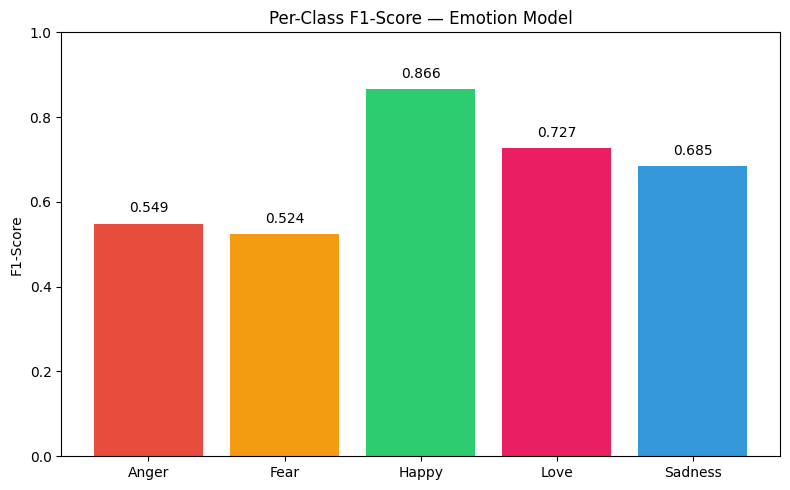

In [49]:
# Per-class F1 bar chart
emotions = ['Anger', 'Fear', 'Happy', 'Love', 'Sadness']
f1_scores = [emo_report[e]['f1-score'] for e in emotions]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(emotions, f1_scores, color=['#e74c3c', '#f39c12', '#2ecc71', '#e91e63', '#3498db'])
ax.set_ylim(0, 1.0)
ax.set_ylabel('F1-Score')
ax.set_title('Per-Class F1-Score — Emotion Model')
for bar, score in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{score:.3f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()